## Darbą atliko Lukas Janušauskas ir Martynas Zabitis

# Bibliotekos, kurias reikės parsisiųsti, kad pasileistų, siūlome pasidaryti laikiną virtual environment:

In [6]:
!! pip install torch==2.10.0 transformers==5.3.0 yfinance==1.2.0 numpy==2.4.2 pandas==3.0.1 PyPortfolioOpt==1.6.0

["'pip' is not recognized as an internal or external command,",
 'operable program or batch file.']

## Bibliotekų importavimas

In [55]:
import numpy as np
import pandas as pd
import yfinance as yf

## Importuojame duomenis

In [56]:
tickers = ["BTC-USD", "GC=F", "BZ=F"]
df = yf.download(tickers, start="2014-01-01")

# Suvienodinti dazni, nes portfeli sudaro kripto ir derivatyvai
df = df.dropna()["Close"]

# Apskaiciuojame grazas
returns = df.pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


In [57]:
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 00)
pd.set_option("display.width", 100)


In [58]:
# 1 užduotis
def compute_rsi(price_series: pd.Series, window: int = 14) -> pd.Series:
    delta = price_series.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(window=window, min_periods=window).mean()
    avg_loss = losses.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi



In [59]:
df['rsi-btc'] = compute_rsi( df['BTC-USD'] )
df['rsi-gold'] = compute_rsi( df['GC=F'] )
df['rsi-brent'] = compute_rsi( df['BZ=F'] )

In [12]:
df

Ticker,BTC-USD,BZ=F,GC=F,rsi-btc,rsi-gold,rsi-brent
Date,,,,,,
2014-09-17,457.334015,98.970001,1234.400024,NaN,NaN,NaN
2014-09-18,424.440002,97.699997,1225.699951,NaN,NaN,NaN
2014-09-19,394.795990,98.389999,1215.300049,NaN,NaN,NaN
2014-09-22,402.152008,96.970001,1216.800049,NaN,NaN,NaN
2014-09-23,435.790985,96.849998,1221.000000,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-03-16,74861.085938,100.209999,4994.000000,71.518810,41.593954,75.458325
2026-03-17,73922.476562,103.419998,5001.000000,63.484111,38.822398,76.718626
2026-03-18,71245.578125,107.379997,4889.899902,57.808703,35.670016,78.259530


In [13]:
df['rsi-signal-btc'] = 0
df.loc[df['rsi-btc'] < 30, 'rsi-signal-btc'] = 1
df.loc[df['rsi-btc'] > 70, 'rsi-signal-btc'] = -1

df['rsi-signal-gold'] = 0
df.loc[df['rsi-gold'] < 30, 'rsi-signal-gold'] = 1
df.loc[df['rsi-gold'] > 70, 'rsi-signal-gold'] = -1

df['rsi-signal-brent'] = 0
df.loc[df['rsi-brent'] < 30, 'rsi-signal-brent'] = 1
df.loc[df['rsi-brent'] > 70, 'rsi-signal-brent'] = -1



In [14]:
df['btc-returns'] = df['BTC-USD'].pct_change()
df['gold-returns'] = df['GC=F'].pct_change()
df['brent-returns'] = df['BZ=F'].pct_change()

In [15]:
btc_svoris = 0.5
gold_svoris = 0.2
brent_svoris = 0.3

df['rsi-returns'] = (
    df['rsi-btc'].shift(1) * df['btc-returns'] * btc_svoris +
    df['rsi-gold'].shift(1) * df['gold-returns'] * gold_svoris +
    df['rsi-brent'].shift(1) * df['brent-returns'] * brent_svoris
)

In [16]:
fin_df = df.copy()

In [17]:
from IPython import display

sharpe_rsi = ( fin_df['rsi-returns'].mean() - 0.03 ) / fin_df['rsi-returns'].std() * np.sqrt(252)
display.Markdown(f"# RSI strategijos sharpe: {sharpe_rsi:.3f}")

# RSI strategijos sharpe: 1.008

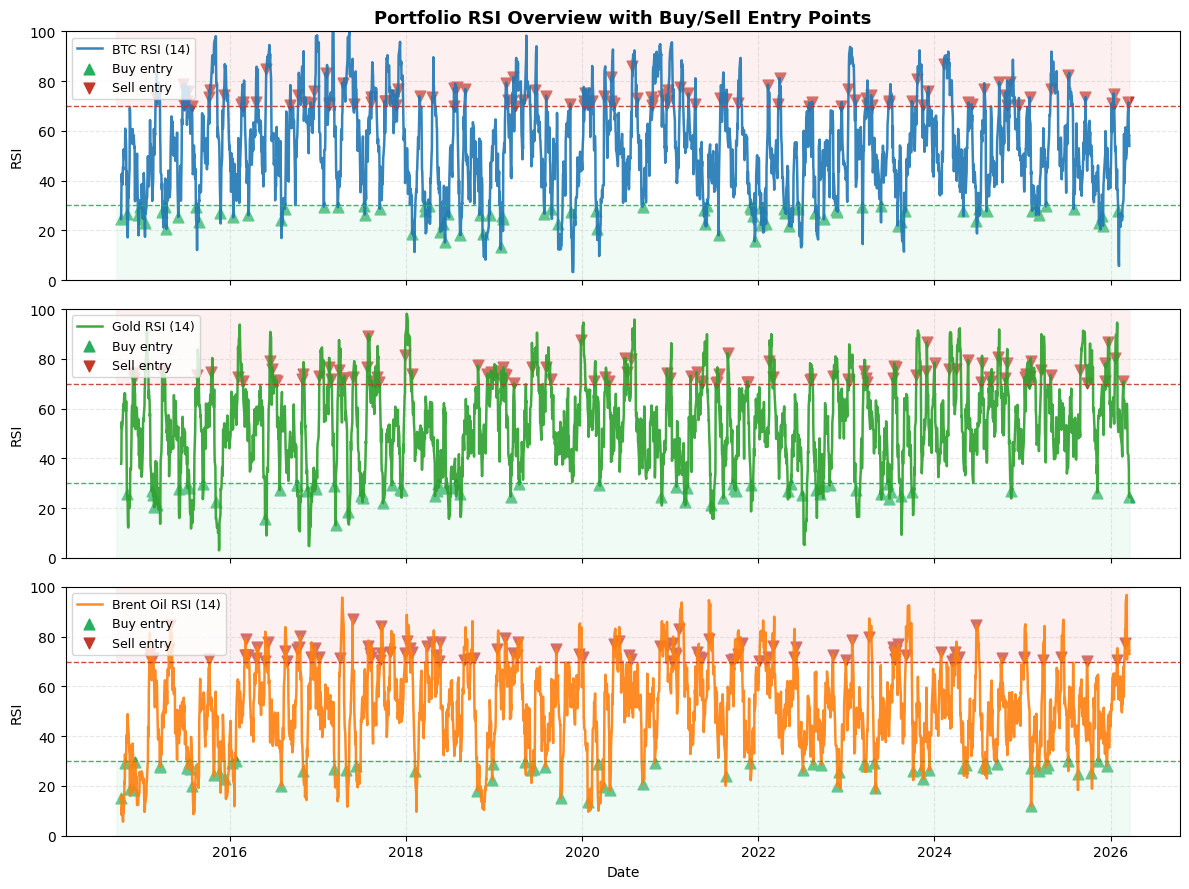

In [69]:
import matplotlib.pyplot as plt
import pandas as pd


def _compute_rsi_local(price_series: pd.Series, window: int = 14) -> pd.Series:
    delta = price_series.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    avg_gain = gains.rolling(window=window, min_periods=window).mean()
    avg_loss = losses.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


asset_map = [
    ('BTC-USD', 'rsi-btc', 'rsi-signal-btc', 'BTC', '#1f77b4'),
    ('GC=F', 'rsi-gold', 'rsi-signal-gold', 'Gold', '#2ca02c'),
    ('BZ=F', 'rsi-brent', 'rsi-signal-brent', 'Brent Oil', '#ff7f0e')
]

for price_column, rsi_column, signal_column, _, _ in asset_map:
    if rsi_column not in df.columns:
        if price_column not in df.columns:
            raise KeyError(f"Missing required column for RSI chart: {price_column}")
        df[rsi_column] = _compute_rsi_local(df[price_column])

    df[signal_column] = 0
    df.loc[df[rsi_column] < 30, signal_column] = 1
    df.loc[df[rsi_column] > 70, signal_column] = -1

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for subplot_axis, (_, rsi_column, signal_column, asset_label, line_color) in zip(axes, asset_map):
    signal_series = df[signal_column]

    # Plot only regime-change points: first buy/sell after a threshold crossing.
    buy_mask = (signal_series == 1) & (signal_series.shift(1) != 1)
    sell_mask = (signal_series == -1) & (signal_series.shift(1) != -1)

    subplot_axis.plot(df.index, df[rsi_column], color=line_color, linewidth=1.8, label=f'{asset_label} RSI (14)', alpha=0.9)
    subplot_axis.scatter(df.index[buy_mask], df.loc[buy_mask, rsi_column], marker='^', color='#27ae60', s=60, alpha=1, label='Buy entry')
    subplot_axis.scatter(df.index[sell_mask], df.loc[sell_mask, rsi_column], marker='v', color='#c0392b', s=60, alpha=1, label='Sell entry')

    subplot_axis.axhline(70, color='#c0392b', linestyle='--', linewidth=1.0, alpha=0.9)
    subplot_axis.axhline(30, color='#27ae60', linestyle='--', linewidth=1.0, alpha=0.9)
    subplot_axis.fill_between(df.index, 70, 100, color='#f9d6d5', alpha=0.35)
    subplot_axis.fill_between(df.index, 0, 30, color='#d5f5e3', alpha=0.35)
    subplot_axis.set_ylim(0, 100)
    subplot_axis.set_ylabel('RSI')
    subplot_axis.grid(True, linestyle='--', alpha=0.3)
    subplot_axis.legend(loc='upper left', fontsize=9)

axes[0].set_title('Portfolio RSI Overview with Buy/Sell Entry Points', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

Grafike matome, kada yra siunčiami pirkimo ir pardavimo signalai pagal 14 dienų vidurkį. Šiuos signalus išsaugosime, kai darysime back-testing. Aiškios koreliacijos tarp aktyvų RSI reikšmių nematome, todėl galime teigti, kad portfelis su šiais aktyvais galėtų būti difersifikuotas.

# Importuojame duomenis snetimentų analizei

In [18]:
# read data\BTC_news_articles.csv
btc_news_df = pd.read_csv("data/BTC_news_articles.csv", sep=';')
btc_news_df = btc_news_df[["title", "newsDatetime"]]

btc_news_df.head()

,title,newsDatetime
0,"Bitcoin (BTC) Loses 200-Day MA, Tries to Hold ...",2021-08-18 09:50
1,Crypto Analyst Lark Davis on Bitcoin: ‘Still G...,2021-08-18 10:10
2,Where I am BUYING Bitcoin,2021-08-18 18:27
3,Twitter’s Jack Dorsey Is Now Mining Bitcoin. H...,2021-08-18 18:56
4,Bitcoin Trading Volume Sinks Without Decisive ...,2021-08-18 19:00


In [19]:
# read data\gold_1.xlsx
gold_news_df_1 = pd.read_excel("data/gold_1.xlsx")
gold_news_df_2 = pd.read_excel("data/gold_2.xlsx")
gold_news_df_3 = pd.read_excel("data/gold_3.xlsx")


In [20]:
gold_news_df_1 = gold_news_df_1.rename(
    columns={'Title':'title', 'Submitted Date':'date'}
)

gold_news_df_2 = gold_news_df_2.rename(
    columns={'title':'title', 'date':'date'}
)

gold_news_df_3 = gold_news_df_3.rename(
    columns={'Title':'title', 'Published Date':'date'}
)

for df in (gold_news_df_1, gold_news_df_2, gold_news_df_3):
    df['date'] = pd.to_datetime(df['date'], utc=True)

In [21]:
all_gold = pd.concat([gold_news_df_1, gold_news_df_2, gold_news_df_3],
                     ignore_index=True)

all_gold = all_gold.sort_values('date')[["title", "date"]]

In [22]:
all_gold

,title,date
0,Comex Gold Speculators 'Miss the Move' as Bull...,2013-10-02 00:00:00+00:00
1,Gold Price Hits $3000 as US Consumer Sentiment...,2016-03-07 00:00:00+00:00
2,"Gold Hits New Dollar Record, $25 Off $3000, as...",2016-10-07 00:00:00+00:00
3,$33 Silver Cuts Gold/Silver Ratio as US Stocks...,2016-11-09 00:00:00+00:00
4,"Gold Rises, Silver Spikes as Stocks Slump Agai...",2016-11-10 00:00:00+00:00
...,...,...
427,Trump's Spending & Inflation 'Look Positive' f...,2025-03-11 00:00:00+00:00
428,Gold Trading Hits Shanghai Record on Trump Vic...,2025-03-12 00:00:00+00:00
429,Gold Prices Regain 'Key' 200-Day Moving Averag...,2025-03-13 00:00:00+00:00
430,"Gold Prices Up 20% in 2016 on Euro NIRP, ETF D...",2025-03-14 00:00:00+00:00


In [23]:
# read data\oil_sentiment_headlines.csv
oil_news_df = pd.read_csv("data/oil_sentiment_headlines.csv")[["date", "headline"]]

oil_news_df

,date,headline
0,2019-01-03,$83.7 billion in Iraq &apos; s oil revenues in...
1,2019-01-10,Study: soda destroys kidneys.
2,2019-01-14,American official: We want Qatar to challenge ...
3,2019-01-15,"Stone decor in houses... happiness, warmth and..."
4,2019-01-15,From inside Haftar prisons... shocking account...
...,...,...
11063,2026-03-10,Iran Vows To Fight On After Trump Hints At Ear...
11064,2026-03-10,"US Dollar Is Still the Dominant Currency, Tema..."
11065,2026-03-10,Trump Signals Possible End to Iran War; Oil sl...
11066,2026-03-10,Today will be 'most intense day' of strikes on...


## Čia importuojame modelį, kurį naudosime. Kadangi dirbame su geopolitika susijusiais duomenimis, reikia modelio, kuris suprastų kontekstą, Vader yra paremtas taisyklėmis, taigi jis neturi jokio "išmokimo", pilno konteksto šis metodas nesupranta, todėl naudosime mašininiu mokymosi pagrįstą modelį: FinBERT

In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch

# pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=-1,
 )


c:\Users\zabit\miniconda3\envs\finbert-cpu311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15412.62it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
def calculate_sentiment(row: pd.Series):
    if row['sentiment_label'] == 'negative':
        return -1 * row['sentiment_score']
    elif row['sentiment_label'] == 'positive':
        return row['sentiment_score']
    else:
        return 0

In [26]:
# Turėtų užtrukti iki 5 minučių

titles = btc_news_df["title"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

btc_news_df = btc_news_df.copy()
btc_news_df["sentiment_label"] = sentiment_labels
btc_news_df["sentiment_score"] = sentiment_scores

btc_news_df.head(10)

,title,newsDatetime,sentiment_label,sentiment_score
0,"Bitcoin (BTC) Loses 200-Day MA, Tries to Hold ...",2021-08-18 09:50,negative,0.750021
1,Crypto Analyst Lark Davis on Bitcoin: ‘Still G...,2021-08-18 10:10,neutral,0.605760
2,Where I am BUYING Bitcoin,2021-08-18 18:27,neutral,0.940171
3,Twitter’s Jack Dorsey Is Now Mining Bitcoin. H...,2021-08-18 18:56,neutral,0.943969
4,Bitcoin Trading Volume Sinks Without Decisive ...,2021-08-18 19:00,negative,0.958768
5,Bitcoin-first Compass Mining Accounts Shut Dow...,2021-08-19 00:15,negative,0.949127
6,JPMorgan Chase reportedly shuts down bank acco...,2021-08-19 10:46,negative,0.958980
7,Bitcoin slides with S&P 500 as Fed signals tap...,2021-08-19 11:32,negative,0.880537
8,BTC Struggles Below Critical 200MA as Global M...,2021-08-19 11:55,neutral,0.658571
9,"Altcoin Index Rises Thanks to ADA, SOL, LUNA a...",2021-08-20 08:30,positive,0.926643


In [19]:
btc_news_df['btc-sentiment'] = btc_news_df.apply(calculate_sentiment, axis='columns')

btc_news_df['day'] = pd.to_datetime(btc_news_df['newsDatetime']).dt.normalize()
btc_sentiment = btc_news_df\
    .groupby('day')\
    ['btc-sentiment']\
    .mean()\
    .to_frame()

NameError: name 'btc_news_df' is not defined

In [28]:
fin_df = pd.merge( 
    btc_sentiment.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

In [29]:
# Turėtų užtrukti iki 5 minučių

titles = all_gold["title"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

all_gold = all_gold.copy()
all_gold["sentiment_label"] = sentiment_labels
all_gold["sentiment_score"] = sentiment_scores

all_gold.head(10)

,title,date,sentiment_label,sentiment_score
0,Comex Gold Speculators 'Miss the Move' as Bull...,2013-10-02 00:00:00+00:00,negative,0.875632
1,Gold Price Hits $3000 as US Consumer Sentiment...,2016-03-07 00:00:00+00:00,negative,0.942899
2,"Gold Hits New Dollar Record, $25 Off $3000, as...",2016-10-07 00:00:00+00:00,positive,0.614647
3,$33 Silver Cuts Gold/Silver Ratio as US Stocks...,2016-11-09 00:00:00+00:00,negative,0.790080
4,"Gold Rises, Silver Spikes as Stocks Slump Agai...",2016-11-10 00:00:00+00:00,negative,0.683250
5,Gold Hits 5-Week EUR and GBP Lows as Trump Tar...,2016-11-22 00:00:00+00:00,negative,0.874837
6,Gold and Silver Rebound as Comex-London Arb Wi...,2017-02-02 00:00:00+00:00,negative,0.937437
7,"Gold Down, Silver Firm as Trump Sends Copper 5...",2017-08-01 00:00:00+00:00,negative,0.660220
8,Germany's 'Debt Explosion' Knocks Gold 5% Off ...,2017-09-25 00:00:00+00:00,negative,0.946500
9,"Gold Hits Record CAD, MXN Prices as Trump's Ta...",2017-09-28 00:00:00+00:00,negative,0.863736


In [30]:
all_gold['gold-sentiment'] = all_gold.apply(calculate_sentiment, axis='columns')

all_gold['day'] = pd.to_datetime(all_gold['date']).dt.normalize()
all_gold = all_gold\
    .groupby('day')\
    ['gold-sentiment']\
    .mean()\
    .to_frame()

all_gold.index = all_gold.index.tz_localize(None).normalize()

In [31]:
fin_df = pd.merge( 
    all_gold.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

In [32]:
# Turėtų užtrukti iki 10 minučių

titles = oil_news_df["headline"].fillna("").astype(str)

sentiment_labels = []
sentiment_scores = []

for title in titles:
    result = finbert_pipeline(title, truncation=True)[0]
    sentiment_labels.append(result["label"].lower())
    sentiment_scores.append(result["score"])

oil_news_df = oil_news_df.copy()
oil_news_df["sentiment_label"] = sentiment_labels
oil_news_df["sentiment_score"] = sentiment_scores

oil_news_df.head(10)

,date,headline,sentiment_label,sentiment_score
0,2019-01-03,$83.7 billion in Iraq &apos; s oil revenues in...,neutral,0.914154
1,2019-01-10,Study: soda destroys kidneys.,neutral,0.879167
2,2019-01-14,American official: We want Qatar to challenge ...,positive,0.845280
3,2019-01-15,"Stone decor in houses... happiness, warmth and...",neutral,0.895805
4,2019-01-15,From inside Haftar prisons... shocking account...,negative,0.787668
5,2019-01-19,Be in Haftar prisons... certificates from the ...,neutral,0.937080
6,2019-01-19,"Because of fuel robbers, an explosion kills do...",negative,0.926140
7,2019-01-21,"After the resumption of a pump from Egypt, doe...",neutral,0.875634
8,2019-01-22,Using dogs and gas... attacking Palestinian pr...,negative,0.626961
9,2019-01-22,"Because of Russia, do Ukraine's gas transmissi...",negative,0.726836


In [33]:
oil_news_df['oil-sentiment'] = oil_news_df.apply(calculate_sentiment, axis='columns')

oil_news_df['day'] = pd.to_datetime(oil_news_df['date']).dt.normalize()
oil_news_df = oil_news_df\
    .groupby('day')\
    ['oil-sentiment']\
    .mean()\
    .to_frame()

oil_news_df.index = oil_news_df.index.tz_localize(None).normalize()

In [34]:
fin_df = pd.merge( 
    oil_news_df.reset_index(),
    fin_df.reset_index(),
    left_on='day',
    right_on='Date',
)\
    .drop(columns=['day'])\
    .set_index('Date')

In [50]:
fin_df

,oil-sentiment,gold-sentiment,btc-sentiment,BTC-USD,BZ=F,GC=F,rsi-btc,rsi-gold,rsi-brent,rsi-signal-btc,rsi-signal-gold,rsi-signal-brent,btc-returns,gold-returns,brent-returns,rsi-returns,btc-sentiment-signal,gold-sentiment-signal,brent-sentiment-signal,combined-btc,combined-gold,combined-oil,returns_sentiment,returns_combined
Date,,,,,,,,,,,,,,,,,,,,,,,,
2021-10-07,-0.913999,-0.561683,-0.306497,53805.984375,81.949997,1757.900024,60.712406,52.995069,72.903687,0,0,-1,-0.028097,-0.001477,0.010730,-0.674715,-1,-1,-1,0,0,-1,NaN,NaN
2022-02-28,-0.099933,0.765300,0.448593,43193.234375,100.989998,1899.400024,48.179571,71.114713,66.747363,0,-1,0,0.101469,0.006838,0.031247,2.841288,1,1,0,0,0,0,-0.061476,-0.009374
2022-06-09,0.000000,0.700449,-0.096499,30111.998047,123.070000,1848.800049,49.178467,53.079446,71.568248,0,0,-1,-0.003388,-0.001674,-0.004127,-0.208642,0,1,0,0,0,0,-0.002029,-0.000000
2022-09-01,0.000000,0.000000,0.175587,20127.140625,92.360001,1696.599976,18.211193,16.090404,41.851956,1,1,0,0.003859,-0.009458,-0.042802,-0.581680,1,0,0,1,0,0,-0.001892,0.000000
2022-10-12,-0.866247,0.000000,-0.894820,19157.445312,92.449997,1670.300049,46.002446,49.888043,53.497359,0,0,0,0.005565,-0.005004,-0.019514,-0.237043,-1,0,-1,0,0,0,0.002783,0.002783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-04,0.275390,-0.190994,0.852122,87222.195312,71.040001,2909.600098,33.959360,49.602426,27.355646,0,0,1,0.013438,0.006712,-0.008098,0.173655,1,-1,1,0,0,1,0.009148,0.006719
2025-03-07,-0.243153,0.218145,0.000000,86742.671875,70.360001,2904.699951,31.795602,53.287604,34.014614,0,0,0,-0.035782,-0.004080,0.012957,-0.603731,0,1,-1,0,0,0,-0.013188,0.003887
2025-03-11,-0.248531,-0.676268,0.000000,82862.210938,69.559998,2912.899902,32.362596,48.903138,26.453480,0,0,1,0.055139,0.007575,0.004042,0.820397,0,-1,-1,0,0,0,0.000303,0.000000


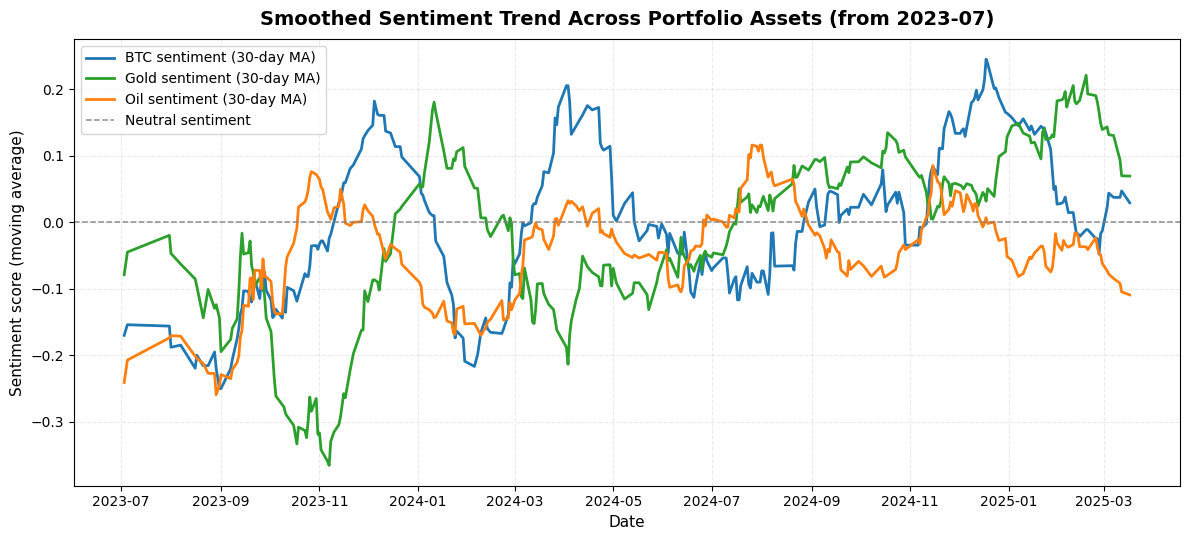

In [ ]:
import matplotlib.pyplot as plt

sentiment_columns = ['btc-sentiment', 'gold-sentiment', 'oil-sentiment']
missing_sentiment_columns = [column_name for column_name in sentiment_columns if column_name not in fin_df.columns]
if missing_sentiment_columns:
    raise KeyError(f"Missing sentiment columns in fin_df: {missing_sentiment_columns}")

sentiment_ma_df = fin_df[sentiment_columns].sort_index().rolling(window=30, min_periods=1).mean()
start_date = '2023-07-01'
sentiment_ma_df = sentiment_ma_df.loc[start_date:]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(sentiment_ma_df.index, sentiment_ma_df['btc-sentiment'], label='BTC sentiment (30-day MA)', color='#1f77b4', linewidth=2)
ax.plot(sentiment_ma_df.index, sentiment_ma_df['gold-sentiment'], label='Gold sentiment (30-day MA)', color='#2ca02c', linewidth=2)
ax.plot(sentiment_ma_df.index, sentiment_ma_df['oil-sentiment'], label='Oil sentiment (30-day MA)', color='#ff7f0e', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.1, alpha=0.9, label='Neutral sentiment')

ax.set_title('Smoothed Sentiment Trend Across Portfolio Assets', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Sentiment score (moving average)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.25)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

Sentimentų grafike galime pastebėti kaip einant laikui keičiasi nuotaika apie Bitcoin, aukso ir naftos. Tai gali padėti kuriant algoritmus, kadangi pozityvi nuotaika apie aktyvą turėtų reikšti, kad aktyvo kaina kyla. Galime pastebėti, kad šiuo metu visų analizuojamų aktyvų nuotaika yra arti neutralios, pozityviausias sentimentas yra aukso.

In [49]:
# save tp csv
fin_df.to_csv("fin_df.csv")

## Agreguojame  signalą iš sentimentų analizės signalų

In [26]:
def sentiment_signals_get_sharpe(df_fin: pd.DataFrame, a: float):
    btc_svoris = 0.5
    gold_svoris = 0.2
    brent_svoris = 0.3

    fin_df['btc-sentiment-signal'] = 0
    fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
    fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

    fin_df['gold-sentiment-signal'] = 0
    fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
    fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

    fin_df['brent-sentiment-signal'] = 0
    fin_df.loc[fin_df['oil-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
    fin_df.loc[fin_df['oil-sentiment'] > a, 'brent-sentiment-signal'] = 1

    sentiment_returns = (
        df_fin['btc-sentiment-signal'].shift(1) * df_fin['btc-returns'] * btc_svoris +
        df_fin['gold-sentiment-signal'].shift(1) * df_fin['gold-returns'] * gold_svoris +
        df_fin['brent-sentiment-signal'].shift(1) * df_fin['brent-returns'] * brent_svoris
    )

    return (sentiment_returns.mean() - 0.03) / sentiment_returns.std()

In [ ]:
thresh = [0.1, 0.2, 0.5, 0.9]
sharpe = [ sentiment_signals_get_sharpe(fin_df, a) for a in thresh ]
best_sharpe = max(sharpe)
best_thresh = thresh[ np.argmax(sharpe) ]

print(best_sharpe, best_thresh)

-2.0770155634351744 0.1


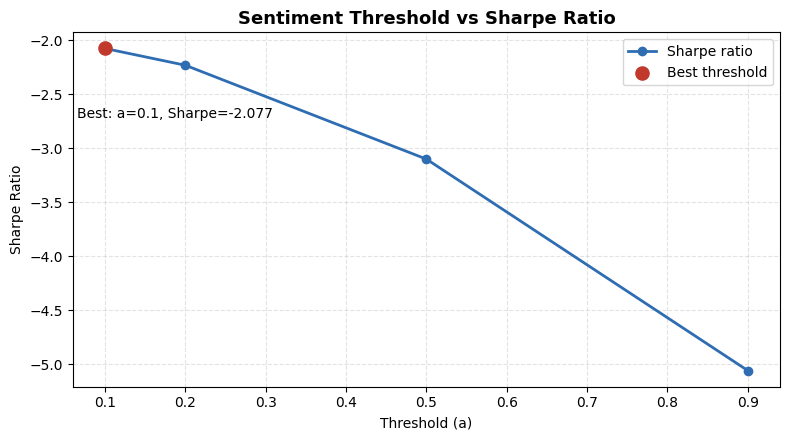

In [37]:
import matplotlib.pyplot as plt

thresh = [0.1, 0.2, 0.5, 0.9]
sharpe = [sentiment_signals_get_sharpe(fin_df, a) for a in thresh]
best_sharpe = max(sharpe)
best_thresh = thresh[np.argmax(sharpe)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresh, sharpe, marker='o', linewidth=2, color='#2f6db2', label='Sharpe ratio')
ax.scatter([best_thresh], [best_sharpe], color='#c0392b', s=90, zorder=3, label='Best threshold')

ax.annotate(
    f"Best: a={best_thresh}, Sharpe={best_sharpe:.3f}",
    (best_thresh, best_sharpe),
    textcoords='offset points',
    xytext=(-20, -50),
    ha='left'
)

ax.set_title('Sentiment Threshold vs Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold (a)')
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
def combined_signals_get_sharpe(df_fin: pd.DataFrame, a: float):
    btc_svoris = 0.5
    gold_svoris = 0.2
    brent_svoris = 0.3

    fin_df['btc-sentiment-signal'] = 0
    fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
    fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

    fin_df['gold-sentiment-signal'] = 0
    fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
    fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

    fin_df['brent-sentiment-signal'] = 0
    fin_df.loc[fin_df['oil-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
    fin_df.loc[fin_df['oil-sentiment'] > a, 'brent-sentiment-signal'] = 1

    fin_df['combined-btc'] = 0
    fin_df.loc[(fin_df['btc-sentiment-signal'] == 1) & (fin_df['rsi-btc'] < 30), 'combined-btc'] = 1
    fin_df.loc[(fin_df['btc-sentiment-signal'] == -1) & (fin_df['rsi-btc'] > 70), 'combined-btc'] = -1

    fin_df['combined-gold'] = 0
    fin_df.loc[(fin_df['gold-sentiment-signal'] == 1) & (fin_df['rsi-gold'] < 30), 'combined-gold'] = 1
    fin_df.loc[(fin_df['gold-sentiment-signal'] == -1) & (fin_df['rsi-gold'] > 70), 'combined-gold'] = -1

    fin_df['combined-oil'] = 0
    fin_df.loc[(fin_df['brent-sentiment-signal'] == 1) & (fin_df['rsi-brent'] < 30), 'combined-oil'] = 1
    fin_df.loc[(fin_df['brent-sentiment-signal'] == -1) & (fin_df['rsi-brent'] > 70), 'combined-oil'] = -1

    sentiment_returns = (
        df_fin['combined-btc'].shift(1) * df_fin['btc-returns'] * btc_svoris +
        df_fin['combined-gold'].shift(1) * df_fin['gold-returns'] * gold_svoris +
        df_fin['combined-oil'].shift(1) * df_fin['brent-returns'] * brent_svoris
    )

    return (sentiment_returns.mean() - 0.03) / sentiment_returns.std()

-6.112858912455501 0.1


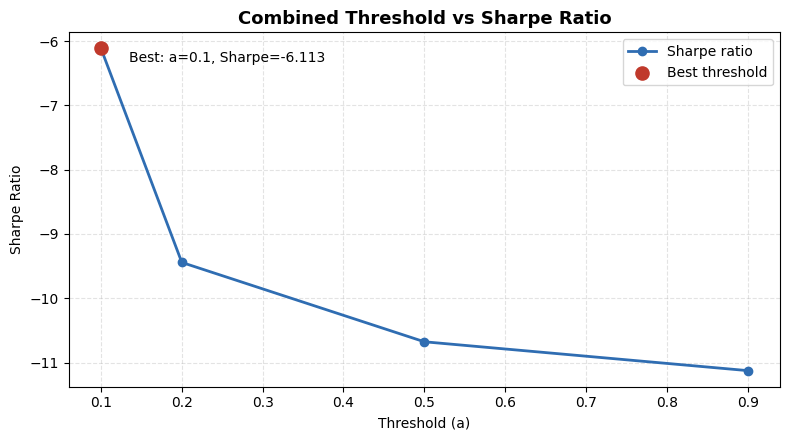

In [42]:
thresh = [0.1, 0.2, 0.5, 0.9]
sharpe = [ combined_signals_get_sharpe(fin_df, a) for a in thresh ]
best_sharpe = max(sharpe)
best_thresh = thresh[ np.argmax(sharpe) ]

print(best_sharpe, best_thresh)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresh, sharpe, marker='o', linewidth=2, color='#2f6db2', label='Sharpe ratio')
ax.scatter([best_thresh], [best_sharpe], color='#c0392b', s=90, zorder=3, label='Best threshold')

ax.annotate(
    f"Best: a={best_thresh}, Sharpe={best_sharpe:.3f}",
    (best_thresh, best_sharpe),
    textcoords='offset points',
    xytext=(20, -10),
    ha='left'
)

ax.set_title('Combined Threshold vs Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold (a)')
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
a = 0.1

fin_df['btc-sentiment-signal'] = 0
fin_df.loc[fin_df['btc-sentiment'] < -1 * a, 'btc-sentiment-signal'] = -1
fin_df.loc[fin_df['btc-sentiment'] > a, 'btc-sentiment-signal'] = 1

fin_df['gold-sentiment-signal'] = 0
fin_df.loc[fin_df['gold-sentiment'] < -1 * a, 'gold-sentiment-signal'] = -1
fin_df.loc[fin_df['gold-sentiment'] > a, 'gold-sentiment-signal'] = 1

fin_df['brent-sentiment-signal'] = 0
fin_df.loc[fin_df['oil-sentiment'] < -1 * a, 'brent-sentiment-signal'] = -1
fin_df.loc[fin_df['oil-sentiment'] > a, 'brent-sentiment-signal'] = 1

fin_df['combined-btc'] = 0
fin_df.loc[(fin_df['btc-sentiment-signal'] == 1) & (fin_df['rsi-btc'] < 30), 'combined-btc'] = 1
fin_df.loc[(fin_df['btc-sentiment-signal'] == -1) & (fin_df['rsi-btc'] > 70), 'combined-btc'] = -1

fin_df['combined-gold'] = 0
fin_df.loc[(fin_df['gold-sentiment-signal'] == 1) & (fin_df['rsi-gold'] < 30), 'combined-gold'] = 1
fin_df.loc[(fin_df['gold-sentiment-signal'] == -1) & (fin_df['rsi-gold'] > 70), 'combined-gold'] = -1

fin_df['combined-oil'] = 0
fin_df.loc[(fin_df['brent-sentiment-signal'] == 1) & (fin_df['rsi-brent'] < 30), 'combined-oil'] = 1
fin_df.loc[(fin_df['brent-sentiment-signal'] == -1) & (fin_df['rsi-brent'] > 70), 'combined-oil'] = -1

fin_df['returns_sentiment'] = (
    fin_df['btc-sentiment-signal'].shift(1) * fin_df['btc-returns'] * btc_svoris +
    fin_df['gold-sentiment-signal'].shift(1) * fin_df['gold-returns'] * gold_svoris +
    fin_df['brent-sentiment-signal'].shift(1) * fin_df['brent-returns'] * brent_svoris
)

fin_df['returns_combined'] = (
    fin_df['combined-btc'].shift(1) * fin_df['btc-returns'] * btc_svoris +
    fin_df['combined-gold'].shift(1) * fin_df['gold-returns'] * gold_svoris +
    fin_df['combined-oil'].shift(1) * fin_df['brent-returns'] * brent_svoris
)

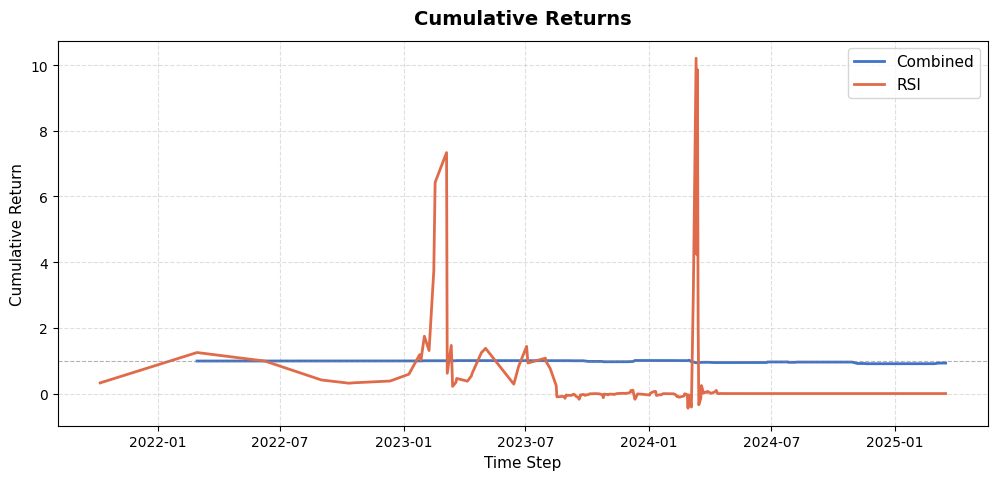

In [42]:
import matplotlib.pyplot as plt

cum_combined = (1 + fin_df['returns_combined']).cumprod()
cum_rsi = (1 + fin_df['rsi-returns']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cum_combined.index, cum_combined, label='Combined', color='#3f72c8', linewidth=2)
ax.plot(cum_rsi.index, cum_rsi, label='RSI', color='#e06b4a', linewidth=2)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title('Cumulative Returns', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Cumulative Return', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

In [43]:
# pip install PyPortfolioOpt

In [45]:
from pypfopt import EfficientFrontier , risk_models , expected_returns

returns_df = fin_df[['returns_sentiment', 'rsi-returns']].dropna()

mu = expected_returns.mean_historical_return(returns_df, returns_data=True, frequency =252)
S = risk_models.sample_cov( returns_df, frequency =252)

ef = EfficientFrontier( mu , S )
weights = ef.min_volatility()

In [46]:
weights

OrderedDict([('returns_sentiment', 0.0973749459003575),
             ('rsi-returns', 0.9026250540996424)])

In [47]:
returns_final = (fin_df['returns_sentiment'] * weights['returns_sentiment'] + fin_df['rsi-returns'] * weights['rsi-returns'])

(returns_final.mean() - 0.03) / returns_final.std() * np.sqrt(252)

np.float64(1.4457923543983084)

In [48]:
print( fin_df['rsi-returns'].std() / np.sqrt(252),
returns_final.std() / np.sqrt(252) )

0.06502917116245316 0.05872765860404888


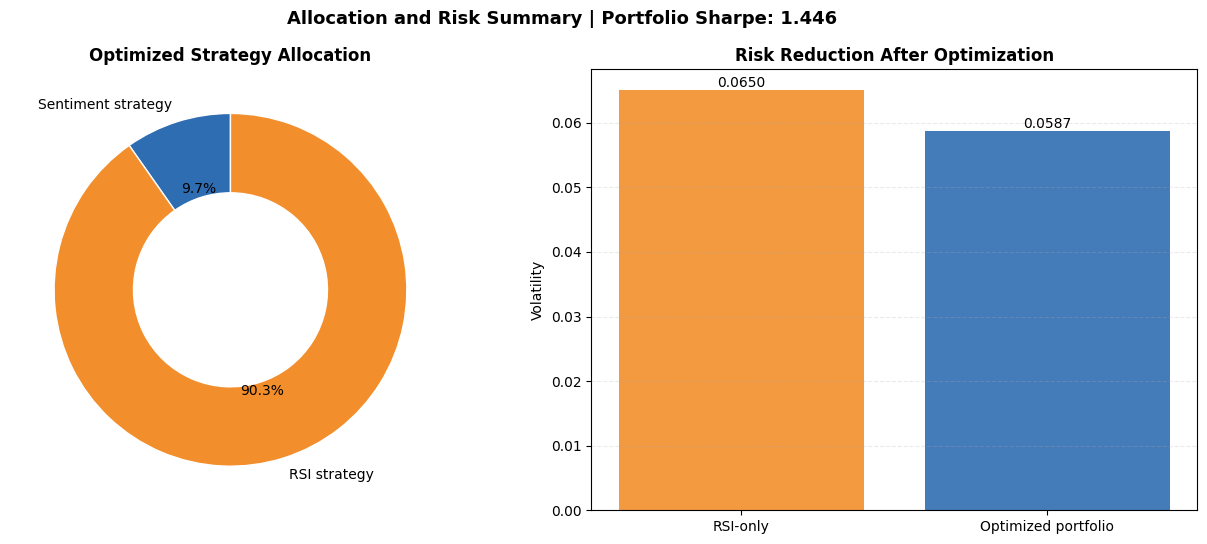

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if 'weights' not in locals() or 'returns_final' not in locals():
    from pypfopt import EfficientFrontier, risk_models, expected_returns

    returns_df = fin_df[['returns_sentiment', 'rsi-returns']].dropna()
    mu = expected_returns.mean_historical_return(returns_df, returns_data=True, frequency=252)
    covariance_matrix = risk_models.sample_cov(returns_df, frequency=252)
    efficient_frontier = EfficientFrontier(mu, covariance_matrix)
    weights = efficient_frontier.min_volatility()
    returns_final = (
        fin_df['returns_sentiment'] * weights['returns_sentiment']
        + fin_df['rsi-returns'] * weights['rsi-returns']
    )

weights_series = pd.Series(weights).reindex(['returns_sentiment', 'rsi-returns'])
weights_pct = weights_series * 100

rsi_vol_display = fin_df['rsi-returns'].std() / np.sqrt(252)
opt_vol_display = returns_final.std() / np.sqrt(252)
sharpe_opt = (returns_final.mean() - 0.03) / returns_final.std() * np.sqrt(252)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

allocation_labels = ['Sentiment strategy', 'RSI strategy']
allocation_colors = ['#2f6db2', '#f28e2b']
axes[0].pie(
    weights_pct.values,
    labels=allocation_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=allocation_colors,
    wedgeprops={'width': 0.45, 'edgecolor': 'white'}
)
axes[0].set_title('Optimized Strategy Allocation', fontweight='bold')

vol_labels = ['RSI-only', 'Optimized portfolio']
vol_values = [rsi_vol_display, opt_vol_display]
vol_colors = ['#f28e2b', '#2f6db2']
bar_container = axes[1].bar(vol_labels, vol_values, color=vol_colors, alpha=0.9)
axes[1].set_title('Risk Reduction After Optimization', fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].grid(axis='y', linestyle='--', alpha=0.25)
for bar_item in bar_container:
    bar_height = bar_item.get_height()
    axes[1].text(
        bar_item.get_x() + bar_item.get_width() / 2,
        bar_height,
        f'{bar_height:.4f}',
        ha='center',
        va='bottom'
    )

fig.suptitle(f'Allocation and Risk Summary | Portfolio Sharpe: {sharpe_opt:.3f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Matome, kad pridėjus sentimentų signalus prie RSI signalų - bendras volatilumas nukrenta apie 10 %.
